In [1]:
import pygmt
import pandas as pd
import numpy as np
import io

In [2]:
# -----------------------------
# Data Input
# -----------------------------
df_lakes = pd.read_csv(
    "../../Processed_Data/Processed_Lake_correct_trend.txt",
    sep='\t',   # handles spaces or tabs
)
df_seismic = pd.read_csv(
    "../../Processed_Data/Declustered_Events_withClosestLake_depth30.txt",
    sep='\t',   # handles spaces or tabs
)

nat_blue = "74/111/165"          # Mediterranean sky blue
res_red = "200/74/61"            # Vermilion / poppy red
# decrease_brown = "139/107/79"        # Warm umber earth
increase_green = "140/180/120"        # Olive landscape green
decrease_purple = "155/115/175"       # Muted aubergine purple
all_lake_neutral = "198/162/82"
grey_background = "235/233/228"


# blue = "168/200/228"
# deepblue = "79/109/138"
# red  = "213/118/107"
# deepred  = "140/63/54"
# bg   = "244/241/237"
line = "139/117/99"

In [3]:
# Split BY TYPE
df_lakes_nat = df_lakes[df_lakes["TypeName"] == 'Natural lake']
df_lakes_res = df_lakes[df_lakes["TypeName"] == 'Reservoir']

In [4]:
# 1) Build a 3-column table: lon, lat, z
tbl = df_seismic[["Longitude", "Latitude", "ClosestLakeDist_km"]].copy()

# Make sure numeric + remove NaNs (GMT doesn't like NaNs)
tbl = tbl.apply(pd.to_numeric, errors="coerce").dropna()

# # 2) Make CPT (required)
# zmin = tbl["ClosestLakeDist_km"].min()
# zmax = tbl["ClosestLakeDist_km"].clip(upper=300).max()
# pygmt.makecpt(cmap="dem2", series=[zmin, zmax])

z = tbl["ClosestLakeDist_km"].to_numpy(float)

# Transparency rule:
# 0   = fully opaque
# 100 = fully transparent
# Linear fade: 0 km -> opaque, 105 km -> transparent
transparency = np.clip(z / 105 * 100, 0, 100)

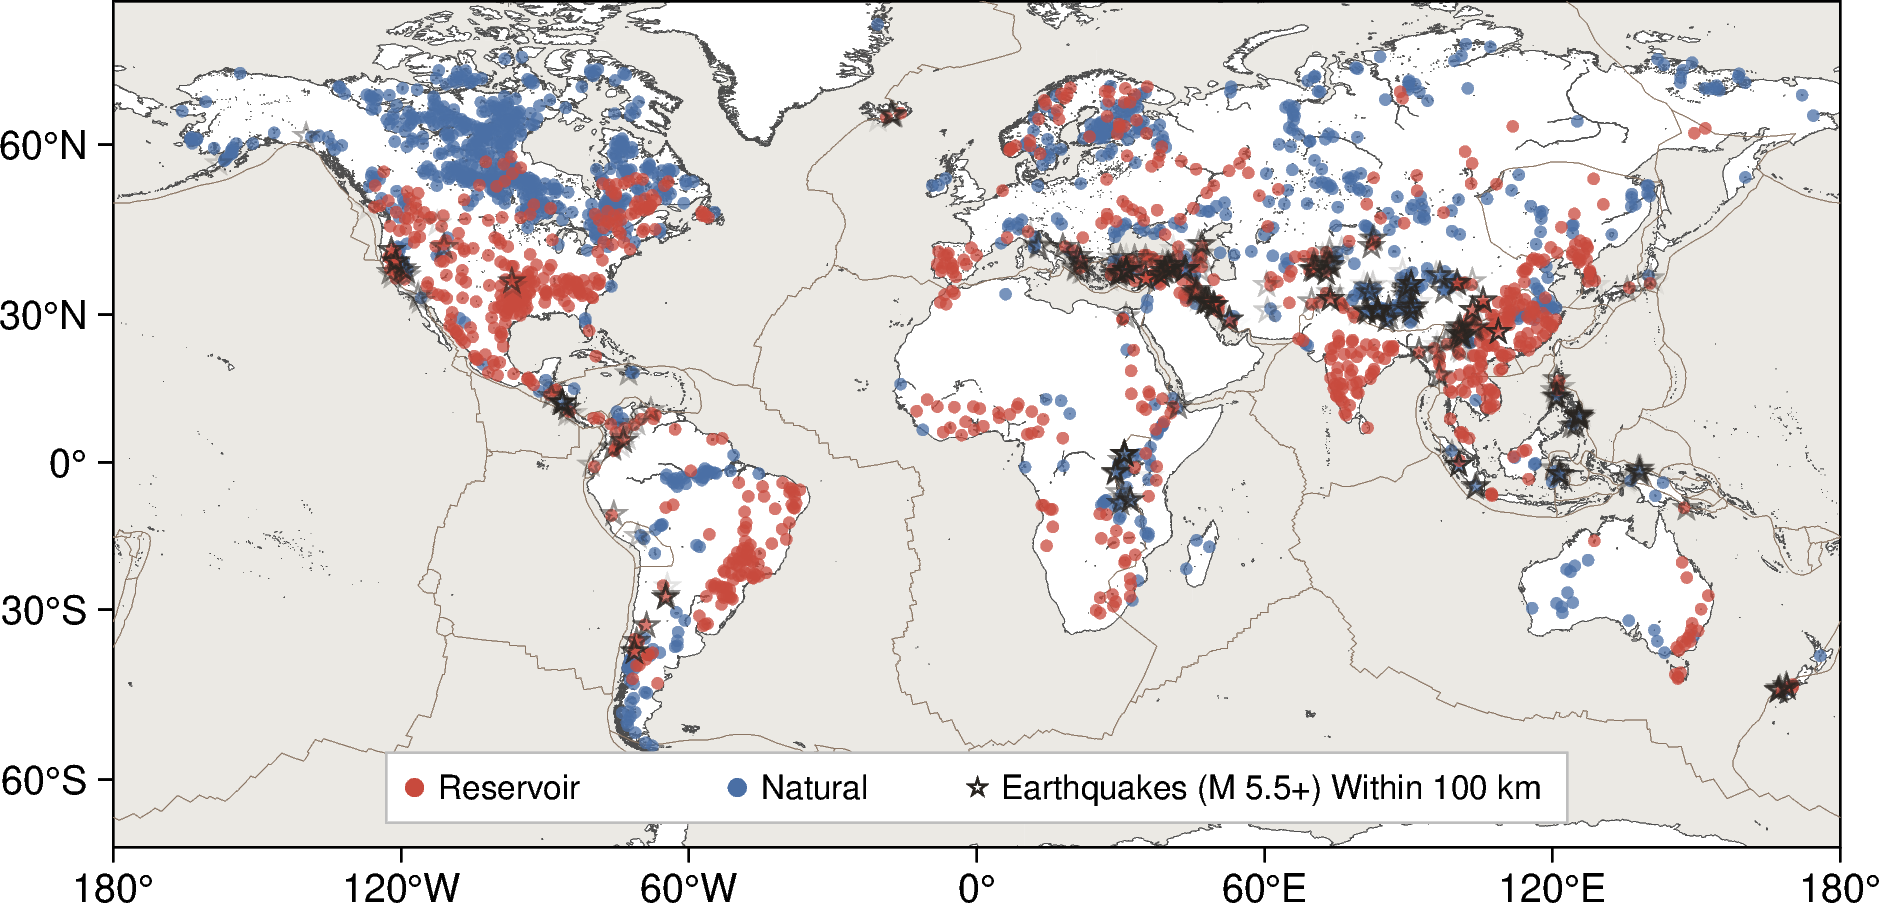

In [5]:
# -----------------------------
# Map settings
# -----------------------------
region = [-180, 180, -70, 80]   # Mercator-friendly global region
map_width_in =  5.7545
map_width_cm = map_width_in * 2.54   # 8.89 cm

projection = f"Cyl_stere/{map_width_cm:.2f}c"   # e.g., Cyl_stere/8.89c

# projection = "Cyl_stere/16c"            # Cylindrical Stereographic projectionn, 18 cm wide

# -----------------------------
# Create figure
# -----------------------------
# ---- common log-size scaling parameters
smin, smax = 0.02, 0.25   # symbol size range in cm
vmin, vmax = 0.01, 0.5   # clip range (your original choice)


legend_spec = f"""
N 3
S 0.1c c 0.15c {res_red}   0.3p,{res_red}   0.3c Reservoir
S -0.5c c 0.15c {nat_blue}  0.3p,{nat_blue}  -0.3c Natural
S -1.8c a 0.15c white                 0.5p,40/36/32           -1.6c Earthquakes (M 5.5+) Within 100 km
"""

# -----------------------------
# Create figure
# -----------------------------
fig = pygmt.Figure()

with pygmt.config(
    MAP_FRAME_TYPE="plain",              # avoid fancy/checker frame behavior
    MAP_FRAME_PEN="0.5p,black@0",          # fully transparent frame line
    MAP_TICK_PEN_PRIMARY="0.5p,black",     # keep ticks
    MAP_TICK_PEN_SECONDARY="0p",         # no minor ticks
    FONT_ANNOT_PRIMARY="9.5p,Helvetica,black",
    FONT_LABEL="8p,Helvetica,black",
):

    # Coastlines and borders
    fig.coast(
        region=region,
        projection=projection,
        water=grey_background,
        shorelines="0.1p,gray30",
        resolution="i", 
        frame=["xa", "ya30"],  # y-axis: annotate every 30, minor ticks every 10
    )

# -----------------------------
# Plate boundaries
# -----------------------------
    fig.plot(
        data="pb2002_boundaries.gmt",  # GMT multi-segment file
        pen=f"0.1p,{line}",
    )
    fig.plot(
        x=df_lakes_nat["X"],
        y=df_lakes_nat["Y"],
        # size=pos_size, 
        # style="c", # this gives a zie depending on the trend magtitude
        style="c0.1c", 
        fill=nat_blue,
        # pen=f"0.3p,{nat_blue}",
        transparency=25,
    )
    fig.plot(
        x=df_lakes_res["X"],
        y=df_lakes_res["Y"],
        # size=pos_size, # this gives a zie depending on the trend magtitude 
        # style="c",
        style="c0.1c", 
        fill=res_red,
        # pen=f"0.3p,{res_red}",
        # pen=None,
        transparency=25,
    )

    fig.plot(
        x=tbl["Longitude"],
        y=tbl["Latitude"],
        style="a0.2c",
        pen="0.5p,40/36/32",      # ← thickness here
        transparency=transparency, # <-- data-driven transparency
        label = "Earthquakes (M 5.5+) +S0.075c",
    )

# Draw the legend (small legend font), separately
with pygmt.config(
    FONT_ANNOT_PRIMARY="8p,Helvetica,black",  # legend text size (most reliable)
    FONT_LABEL="8p,Helvetica,black",
):    
    fig.legend(
        # inside map, bottom-right
        position="JBC+o0c/-0.8c+w10c"
        ,box="+gwhite@0+p0.5p,gray"
        , spec=io.StringIO(legend_spec))
# -----------------------------
# Show / save
# -----------------------------
    fig.show()
    fig.savefig("fig1_a.pdf", dpi=300)